In [1]:
pip install imbalanced-learn

40
      SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0                 0       1           29.85         29.85        False   
1                 0      34           56.95       1889.50         True   
2                 0       2           53.85        108.15         True   
3                 0      45           42.30       1840.75         True   
4                 0       2           70.70        151.65        False   
...             ...     ...             ...           ...          ...   
7038              0      24           84.80       1990.50         True   
7039              0      72          103.20       7362.90        False   
7040              0      11           29.60        346.45        False   
7041              1       4           74.40        306.60         True   
7042              0      66          105.65       6844.50         True   

      Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0            True           False             False  

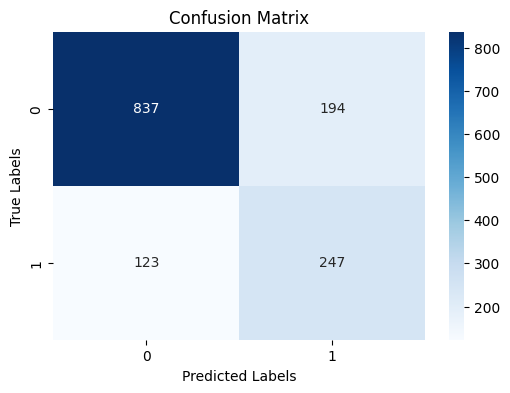

                                  feature  importance
1                                  tenure    0.163920
28         PaymentMethod_Electronic check    0.149430
3                            TotalCharges    0.109018
10            InternetService_Fiber optic    0.085501
2                          MonthlyCharges    0.081578
25                      Contract_Two year    0.074434
26                   PaperlessBilling_Yes    0.065030
24                      Contract_One year    0.029777
9                       MultipleLines_Yes    0.018178
4                             gender_Male    0.018092
8          MultipleLines_No phone service    0.017238
21                        StreamingTV_Yes    0.016518
23                    StreamingMovies_Yes    0.015349
16   DeviceProtection_No internet service    0.013291
27  PaymentMethod_Credit card (automatic)    0.012646
29             PaymentMethod_Mailed check    0.011710
18        TechSupport_No internet service    0.011504
13                     Onlin

['customer_churn_model.pkl']

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier

# load dataset

df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')


# drop the cutomerId column since it will have no use in training

df = df.drop('customerID', axis = 1)

# convert to numeric values , coerece = Nan

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors = 'coerce')

# drop the churn column since it's used in the the y variable as output
# model mustnt train on it since it leads to byherating instaed of understanding pattern

y = df['Churn']
df = df.drop('Churn', axis = 1)


# if the column values are string then we need to encode them

df = pd.get_dummies(df, drop_first=True)

# fill the null or Nan values in numeric column with the mean/mode/median
# median we use it when data is normally disributed
# mode we use when for categorical data hence we replace Nan with most frequent
# mean we use when data is very skewed

df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].mean())
print(df.duplicated().sum())
df = df.drop_duplicates()
print(df)


for col in ['TotalCharges', 'MonthlyCharges']:
  median_value = df[col].median()
  df[col] = df[col].apply(lambda x : median_value if x > 3500 or x < 0 else x)



# train test split

X = df.copy()

y_aligned = y.loc[X.index]

x_train, x_test, y_train, y_test = train_test_split(X, y_aligned, stratify = y_aligned, test_size = 0.2, random_state = 42)
print(f"x_train : {x_train.shape}",
      f"x_test : {x_test.shape}",
      f"y_train : {y_train.shape}",
      f"y_test : {y_test.shape}")

smote = SMOTE(random_state=42)

x_train_smote, y_train_smote = smote.fit_resample(
    x_train,
    y_train )


# scaling the data
scaler = StandardScaler()

# fit and transform data
scaler.fit(x_train_smote)

x_train = scaler.transform(x_train_smote)
x_test = scaler.transform(x_test)


x_train_scaled = pd.DataFrame(x_train, columns = X.columns)
x_test_scaled = pd.DataFrame(x_test, columns = X.columns)

# use

print(x_train_scaled.sample(5))


from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(

    n_estimators=300,       # number of trees

    criterion='gini',       # split quality measure

    max_depth=10,           # maximum depth of tree

    min_samples_split=5,    # minimum samples to split node

    min_samples_leaf=2,     # minimum samples in leaf node

    max_features='sqrt',    # features considered per split

    bootstrap=True,         # sampling with replacement

    oob_score=True,         # out-of-bag evaluation

    class_weight='balanced',# handles class imbalance

    random_state=42,        # reproducibility

    n_jobs=-1               # use all CPU cores
    )



rf_model.fit(x_train, y_train_smote)

# after training model on training data we can predict now

y_pred = rf_model.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy score : {accuracy}")

print(f"precision : {precision_score(y_test, y_pred, pos_label = 'Yes')}")

print(f"recall score : {recall_score(y_test, y_pred, pos_label = 'Yes')}")

print(f"f1-score : {f1_score(y_test, y_pred, pos_label = 'Yes')}")

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

plt.figure(figsize = (6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot = True, fmt = 'd', cmap = 'Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({'feature': X.columns, 'importance': importance})
print(feature_importance.sort_values(by = 'importance', ascending = False))


import joblib

joblib.dump(rf_model, "customer_churn_model.pkl")

In [5]:
print(f" ytrain : {y_train.value_counts()}")
print(f" y_test : {y_test.value_counts()}")
print(f" y_train_smote : {(y_train_smote.value_counts())} ")

 ytrain : Churn
No     4125
Yes    1477
Name: count, dtype: int64
 y_test : Churn
No     1031
Yes     370
Name: count, dtype: int64
 y_train_smote : Churn
No     4125
Yes    4125
Name: count, dtype: int64 


### Target Variable Distribution

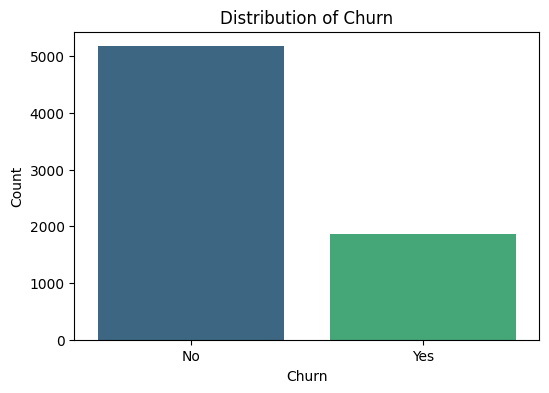

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x=y, hue=y, palette='viridis', legend=False)
plt.title('Distribution of Churn')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

### Distribution of Numerical Features

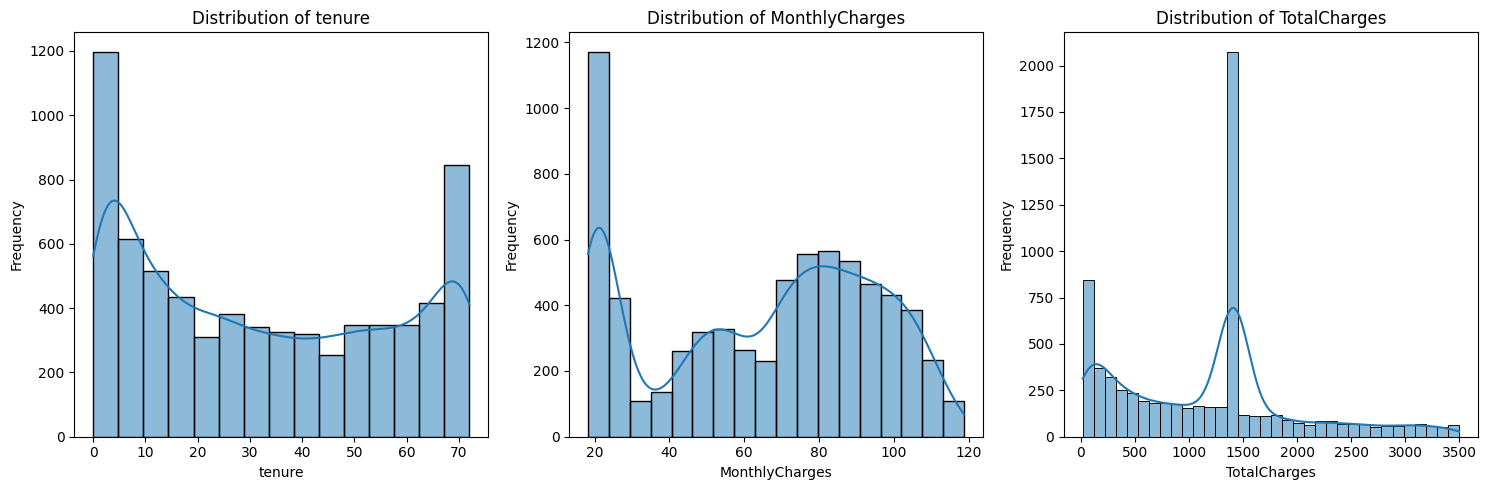

In [7]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i + 1)
    sns.histplot(X[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()